# **Atividade Prática**
<font size=3>

- **Tema:** métodos baseados em árvores.
- **Prazo de entrega:** 14 de Maio.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSeHK5qrS-_wttHK6XXKBK2-SXv1nxU3Xhk8x__eP1ZrHulHDw/viewform?usp=header).

---

### **1. Questão:** 
<font size=3>

Com base no *dataset* de [classificação de dígitos](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html), realize os seguintes passos:

1. **Importe os dados** nas variáveis de atributos (`X`) e alvo (`y`). Este *dataset* apresenta imagens de dígitos manuscritos em formato de *arrays* unidimensionais e suas "etiquetas" como números interios de 0 a 9;  

2. **Escreva** em uma **cálula _markdown_** do que se tratam os atributos dos dados de entrada;

3. Plote a imagem de um dígitos utilizando a função [`imshow`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html). Aqui será necessário fazer o *reshape* da imagem $(64,)$ para $(8\times 8)$;

4. Para o modelo [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) se faz necessário pré-processamento dos dados de entrada e alvo? **Justifique sua resposta** em uma **cálula _markdown_**.

5. Treine este modelo, utilizando o [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) para afinar os hyperparâmetros de poda. **Imprima na tela** os melhores valores de hiperparâmetros;

5. Utilize as funções [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html), [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) e [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) para interpretar os resultados. Existem características em comuns nos dois dígitos de melhor classificação? **Justifique sua resposta** em uma **cálula _markdown_**. 


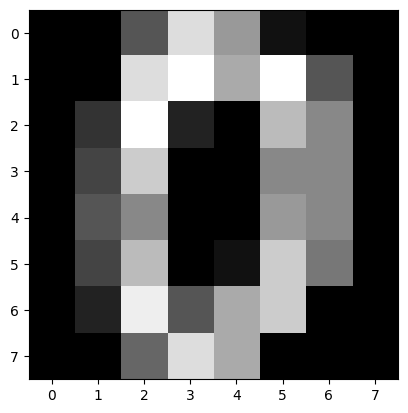

In [42]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
import matplotlib.pyplot as plot

# from google.colab import drive
# drive.mount('/content/drive') 
# from google.colab import drive
# drive.mount('/content/drive') 

dataset = load_digits()
x = pd.DataFrame(dataset.data)
y = dataset.target

img_matrix = x.iloc[0].values.reshape(8, 8)
plot.imshow(img_matrix, cmap='gray', )
plot.show()




### **2. Questão:** 
<font size=3>

Com base no *dataset* de [Classificação de Poemas](https://www.kaggle.com/datasets/ramjasmaurya/poem-classification-nlp), disponível no diretório $\text{dataset/}\,$, realize os seguintes passos:

1. Importe o *dataset* e defina os poemas como a variável de atributos e os gêneros como a variável alvo;

2. Utilize a função [`TfidfVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) para quebrar os poemas em listas de palavras, e transformar estas em representações numéricos, considerando as variáveis:
    <font size=2>

    ```python
    vectorizer = TfidfVectorizer(lowercase=True, 
                                 stop_words="english", 
                                 token_pattern=r"\b[a-zA-Z]{2,}\b", 
                                 min_df=2))
                                 
    ```

3. **Escreva** em uma **célula _markdown_** do que se trata os atributos dos dados de entrada;

4. Com o [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html), faça o encadeamento do vetorizador com o modelo [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html);

5. **Escreva** em uma **célula _markdown_** as características do algoritmo do *random forest* que mitigam o *overfitting*;

6. Encontre os melhores hiperparâmetros de poda e número de árvores com o  [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html).

7. Para plotar os atributos de maior importância, adapte as seguintes linhas de código na sua implementação:
    <font size=2>

    ```python
    best_pipe = random_search.best_estimator_
    
    vectorizer = best_pipe.named_steps['vectorizer']
    random_forest = best_pipe.named_steps['model']
    
    feature_names = vectorizer.get_feature_names_out()
    feature_importances = random_forest.feature_importances_
    ```
    <font size=3>
    <br>
        
    Com os *arrays* `feature_names` e `feature_importance`, faça o gráfico de barras das 10 palavras mais importantes para as classificações (ver **_notebook_ 10** para o gráfico de barras).

8. Utilize a função [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) para interpretar os resultados. **Escreva** em uma **cálula _markdown_** sua interpretação quanto ao desempenho das classificações do seu modelo.
    

### **3. Questão:** 
<font size=3>

Com base no *dataset* de [Performance Acadêmica](https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance), disponível no diretório $\text{dataset/}\,$, realize os seguintes passos:

1. Importe o *dataset* e defina o atributo `exam_score` como a variável alvo para **regressão**, e os demais atributos como entrada do modelo;

2. Utilize o [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) para encadear o pré-processamento [`OrdinalEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html) dos atributos categóricos com o modelo [`GradientBoostingRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html). **Dica:** para que apenas os atributos categóricos passem pelo pré-processamento, e as demais não, utilize o [`ColumnTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) com a variável `remainder = "passthrough"`;

3. **Escreva** em uma **célula _markdown_** as semelhanças e diferenças entre o modelo *gradient booting* e o *random forest*;

4. Plote o gráfico de barras da importâncias dos atributos e, com base nele, **escreva** em uma **célula _markdown_** um breve relatório sobre quais atributos são mais relevantes e os menos relevantes. Desenvolva uma análise interpretativa do porquê esses atributos se destacam desta forma.

5. Para avaliação do modelo, **imprima na tela** o valores de MSE e $R^2$ entre os dados de predição e teste.
